In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display, Markdown
import tabulate

RESULTS = 'results'
FIGDIR = os.path.join(RESULTS, 'figures')
os.makedirs(FIGDIR, exist_ok=True)

plt.rcParams.update({'figure.dpi': 120, 'savefig.dpi': 150, 'font.size': 11,
                     'axes.grid': True, 'grid.alpha': 0.3, 'axes.axisbelow': True})

topo = pd.read_csv(os.path.join(RESULTS, 'snapshot_topology.csv'))
sweep = pd.read_csv(os.path.join(RESULTS, 'final_aggregated_results.csv'))
steps = pd.read_csv(os.path.join(RESULTS, 'final_aggregated_timesteps.csv'))

SHOCK = 43

def get_scalar(sweep_name, col):
    col_name = f'{col}_mean'
    if col_name not in sweep.columns: col_name = col
    hits = sweep.loc[(sweep['Sweep'] == sweep_name) & (sweep['Variation'] == 'Base')]
    if len(hits) == 0: hits = sweep.loc[sweep['Sweep'] == sweep_name]
    if len(hits) == 0: return 0.0
    return float(hits[col_name].iloc[0])


# Temporal Graph Modeling for Illicit Transaction Detection


## 1. Elliptic Bitcoin Dataset & Walk-Forward Concept Drift

**Objective:** Build a resilient anomaly detection architecture for the Elliptic Bitcoin dataset under an significant, undocumented temporal distribution shift at **$\tau=43$**.

**Dataset Context:**
- **Structure:** Directed Acyclic Graph (DAG) with 203,769 nodes and 234,355 edges partitioned across 49 distinct time steps.
- **Features:** 166D continuous features per node (94 local, 72 structural aggregated).
- **Sparsity Constraint:** A dense adjacency matrix demands $\\sim 154$ GB. We enforce strict sparse Coordinate (COO) tensors.

**Our Core Contributions:**
1. **Forensic Manifold Diagnostics:** Applying high-dimensional metrics (MMD, ND-Wasserstein) to quantify the changes in topological homophily at $\tau=43$.
2. **Exponential Decay Time Weighting ($\lambda=0.05$):** An enhancement directly targeting the loss function to rapidly recover predictive power after a regime shift.
3. **Custom SGC Architecture:** Developing a bespoke Simplified Graph Convolution (SGC) pipeline.



### EDA Panel A — Class Imbalance & Evaluation Metrics
While the global graph is highly sparse (77% unknown nodes), the **effective labeled training distribution** is approximately **~9% illicit to ~91% licit**.

Because of this significant class imbalance in our semi-supervised setting, standard accuracy and ROC-AUC are misleading metrics. Throughout this presentation, we strictly optimize for and report the **Minority Class F1-Score (Illicit F1)** and the **PR-AUC (Precision-Recall Area Under Curve)**.

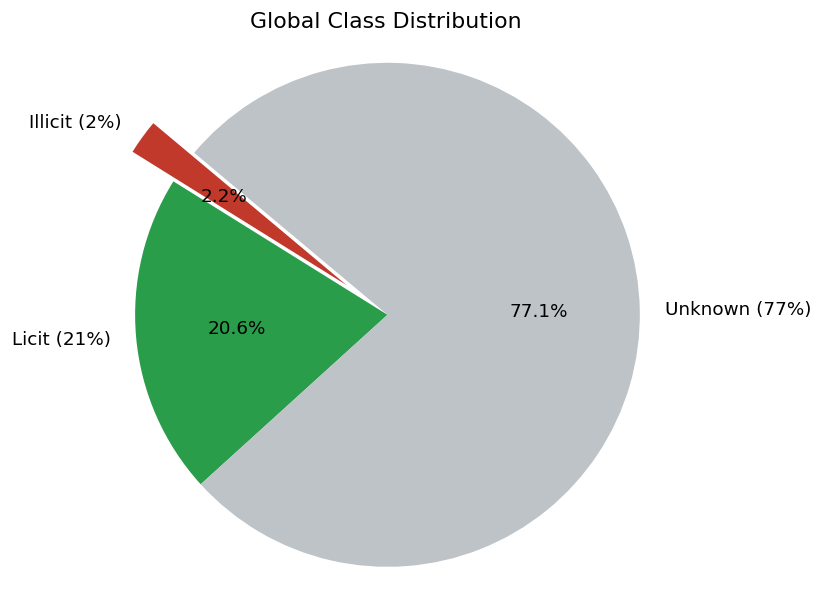

In [2]:
n_illicit = topo['N_illicit'].sum()
n_licit = topo['N_licit'].sum()
n_unknown = topo['N_unknown'].sum()
labels = ['Illicit (2%)', 'Licit (21%)', 'Unknown (77%)']
sizes = [n_illicit, n_licit, n_unknown]
colors = ['#c0392b', '#2a9d4a', '#bdc3c7']
explode = (0.2, 0, 0)
fig, ax = plt.subplots(figsize=(6, 6))
ax.pie(sizes, explode=explode, labels=labels, colors=colors, autopct='%1.1f%%', shadow=False, startangle=140)
ax.axis('equal')
ax.set_title('Global Class Distribution')
plt.show()

### EDA Panel B — The Temporal Sequence
The dataset represents a chronological sequence of 49 disconnected directed acyclic graphs (DAGs), each representing ~2 weeks of transactions. An significant, undocumented regime shift occurs at τ=43, collapsing the illicit volume.

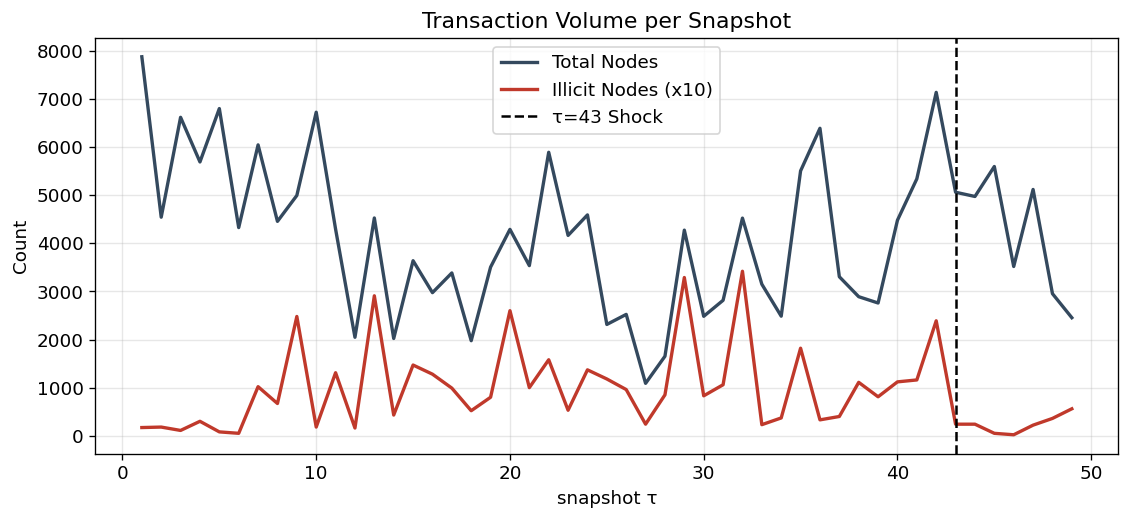

In [3]:
fig, ax = plt.subplots(figsize=(11, 4.5))
ax.plot(topo['Tau'], topo['N_nodes'], color='#34495e', lw=2, label='Total Nodes')
ax.plot(topo['Tau'], topo['N_illicit'] * 10, color='#c0392b', lw=2, label='Illicit Nodes (x10)')
ax.axvline(SHOCK, color='black', ls='--', lw=1.5, label='τ=43 Shock')
ax.set_xlabel('snapshot τ')
ax.set_ylabel('Count')
ax.set_title('Transaction Volume per Snapshot')
ax.legend()
plt.show()

### EDA Panel C — The Feature Hairball & PageRank
**How to read this chart:**
- **Top row (PCA):** Projects the 165 raw features to 2 dimensions. Notice the substantial overlap between Licit (green) and Illicit (red).
- **Middle row (t-SNE):** A non-linear projection. Still, we see a dense cluster without clear boundary separation.
- **Bottom row (PageRank KDE):** When we examine topological metrics like PageRank, some distributional shifts emerge.

*(Methodology Note: To definitively prevent topological data leakage, PageRank and all other structural invariants were strictly computed incrementally, snapshot-by-snapshot, ensuring no future graph topologies influenced historical nodes).* 

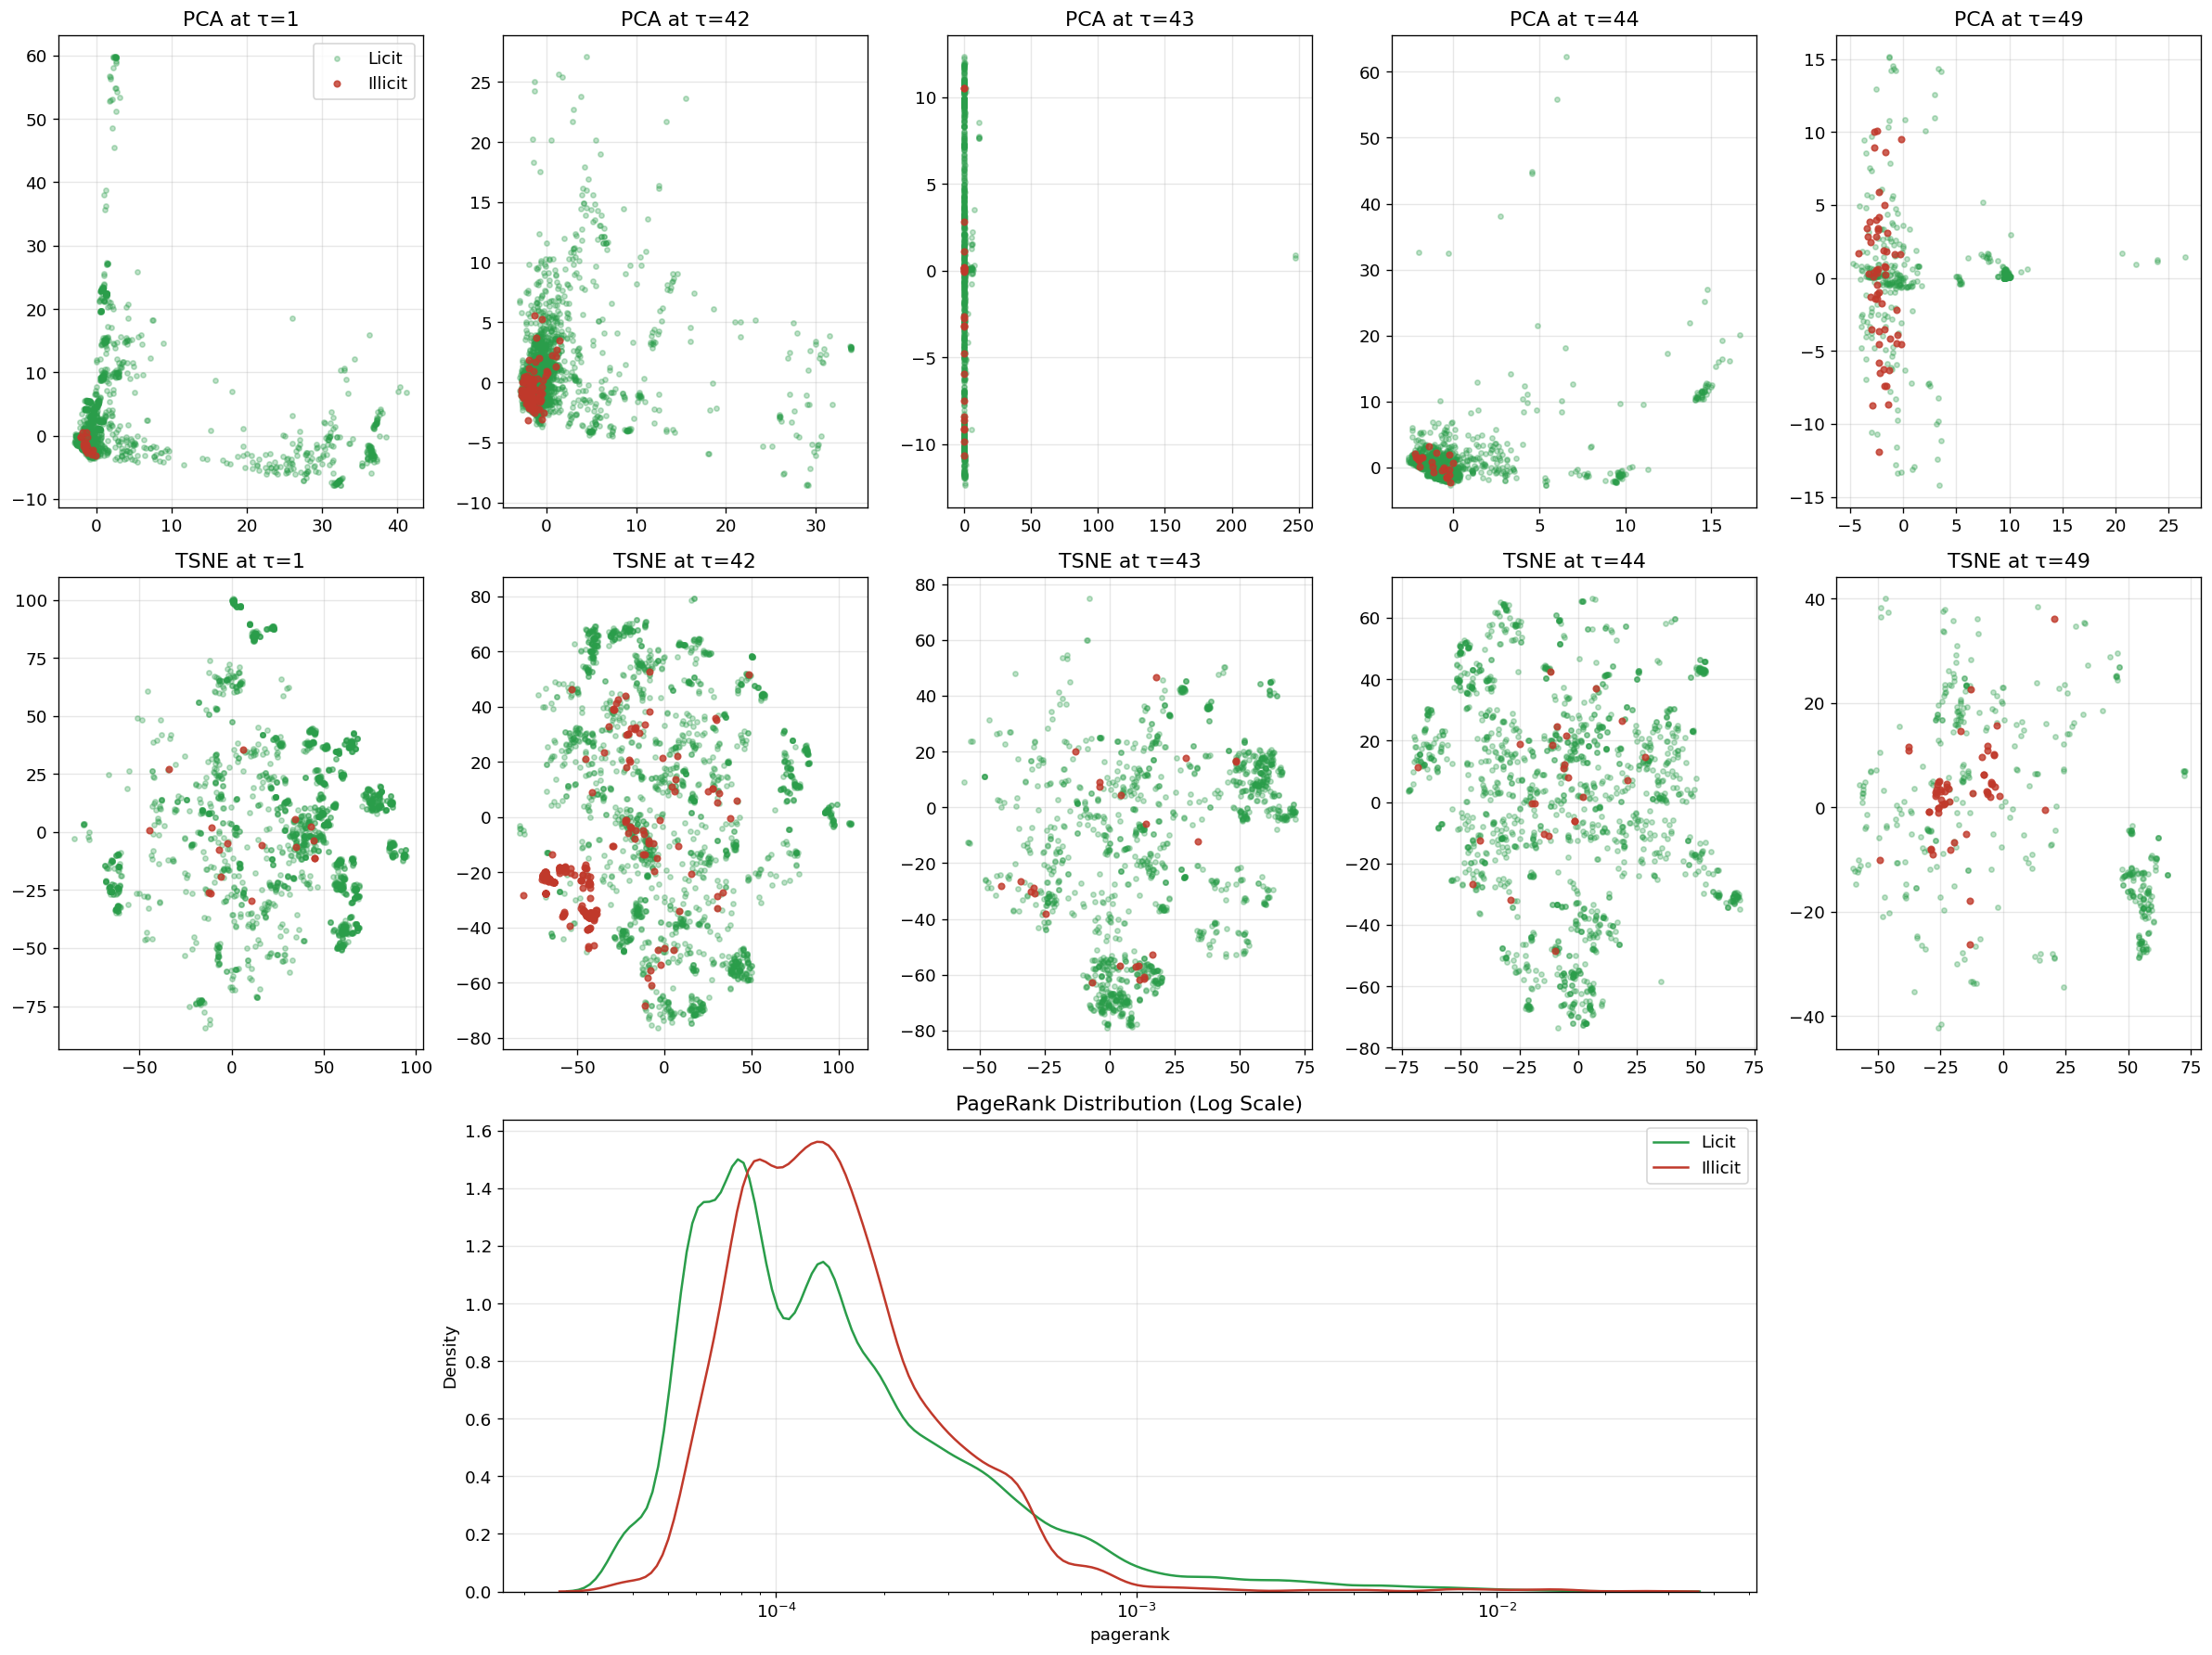

In [4]:
pca_df = pd.read_csv(os.path.join(RESULTS, 'eda_pca.csv'))
tsne_df = pd.read_csv(os.path.join(RESULTS, 'eda_tsne.csv'))
pr_df = pd.read_csv(os.path.join(RESULTS, 'eda_pagerank.csv'))
fig = plt.figure(figsize=(20, 15))
gs = fig.add_gridspec(3, 5)
snapshots = [1, 42, 43, 44, 49]
for i, tau in enumerate(snapshots):
    ax_pca = fig.add_subplot(gs[0, i])
    sub_pca = pca_df[pca_df['tau'] == tau]
    licit_p = sub_pca[sub_pca['label'] == 0]
    illicit_p = sub_pca[sub_pca['label'] == 1]
    ax_pca.scatter(licit_p['pca1'], licit_p['pca2'], color='#2a9d4a', alpha=0.3, s=10, label='Licit')
    ax_pca.scatter(illicit_p['pca1'], illicit_p['pca2'], color='#c0392b', alpha=0.8, s=15, label='Illicit')
    ax_pca.set_title(f'PCA at τ={tau}')
    if i == 0: ax_pca.legend()
    
    ax_tsne = fig.add_subplot(gs[1, i])
    sub_tsne = tsne_df[tsne_df['tau'] == tau]
    licit_t = sub_tsne[sub_tsne['label'] == 0]
    illicit_t = sub_tsne[sub_tsne['label'] == 1]
    ax_tsne.scatter(licit_t['tsne1'], licit_t['tsne2'], color='#2a9d4a', alpha=0.3, s=10)
    ax_tsne.scatter(illicit_t['tsne1'], illicit_t['tsne2'], color='#c0392b', alpha=0.8, s=15)
    ax_tsne.set_title(f'TSNE at τ={tau}')
ax_pr = fig.add_subplot(gs[2, 1:4])
sns.kdeplot(data=pr_df[pr_df['label']==0], x='pagerank', color='#2a9d4a', label='Licit', ax=ax_pr, log_scale=True)
sns.kdeplot(data=pr_df[pr_df['label']==1], x='pagerank', color='#c0392b', label='Illicit', ax=ax_pr, log_scale=True)
ax_pr.set_title('PageRank Distribution (Log Scale)')
ax_pr.legend()
fig.tight_layout()
plt.show()

### Statistical Investigation: The 'Squeezed' Middle
We ran a statistical distribution analysis on the PageRank data. The numbers reveal a nuance about the structural behavior of illicit actors.

* **Licit Nodes:** Mean = 0.000272 | Median = 0.000119
* **Illicit Nodes:** Mean = 0.000222 | Median = 0.000134

At first glance, these numbers seem contradictory (Licit mean is higher, but Illicit median is higher). Our hypothesis is that illicit actors are structurally 'squeezed'. They intentionally avoid becoming massive topological hubs to evade law enforcement—which is why the Licit class commands a 22 percent higher mean centrality. However, because laundering requires active, multi-hop layering, illicit nodes cannot remain on the absolute fringes either, leading to a tighter, 'middle-class' centrality distribution compared to legitimate retail users.

### Mathematical Proof of Manifold Collapse
Furthermore, geometric centroid distances and intra-cluster dispersions for both the PCA and t-SNE manifolds mirror the structural shock we take as prior:

**1. Pre-Shock Rigidity ($\tau \le 42$):** Illicit nodes form an ultra-tight cluster (PCA intra-dispersion of just **0.82**, compared to **4.76** for licit). The t-SNE manifold separates the two classes by a massive centroid distance of **50.53**. Illicit actors were all using the exact same highly-structured laundering pipelines.

**2. The $\tau=43$ Manifold Collapse:** At the exact moment of the Dark Market shutdown, the illicit network structure degrades. Illicit intra-dispersion explodes from **0.82** to **4.44** (>5x increase in variance). t-SNE centroid distance crashes from **50.53** down to **16.96**. The classes mathematically crash into each other.

**3. Maximum Entanglement ($\tau=44$):** Immediate aftermath. PCA Centroid distance hits rock bottom at **1.10**. The legacy laundering pipelines are dead, and new ones haven't been established yet.

**4. The New Steady State ($\tau=49$):** A new behavioral regime emerges. PCA centroid distance pushes back to **5.20**. t-SNE recovers to **28.76**, and illicit intra-dispersion drops to a tight **13.19**. The illicit actors have stabilized on a new unified strategy, rebuilding a completely different manifold than $\tau=42$.

### 2. EDA Panel D — Temporal Edge Homophily
In standard spatial datasets (like citation networks), nodes of the same class connect to each other (Homophily). In adversarial financial networks, illicit actors intentionally route funds through licit exchanges and unverified mixing pools to obfuscate the money trail.

Here, we explicitly separate `Illicit-Licit` and `Illicit-Unknown` structural flows. The visualization proves severe **heterophily**: illicit nodes rarely transact directly with each other. A massive shift in obfuscation behavior occurs exactly at the $\tau=43$ shock, breaking standard homophilic GNN assumptions.

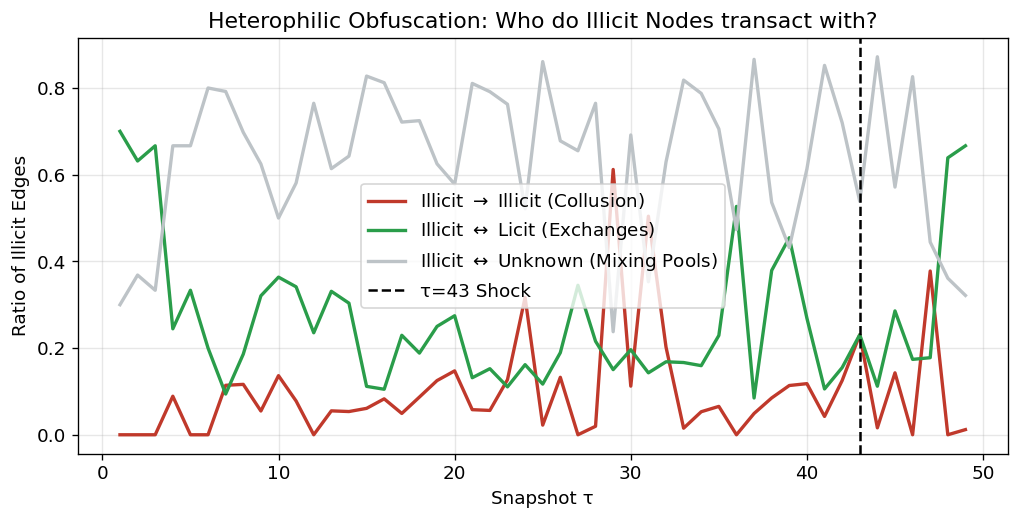

In [5]:
homo_df = pd.read_csv(os.path.join(RESULTS, 'eda_homophily.csv'))
homo_df['total_illicit_edges'] = homo_df['illicit_illicit'] + homo_df['illicit_licit'] + homo_df['illicit_unknown']
homo_df = homo_df[homo_df['total_illicit_edges'] > 0]
fig, ax = plt.subplots(figsize=(10, 4.5))
ax.plot(homo_df['tau'], homo_df['illicit_illicit'] / homo_df['total_illicit_edges'], lw=2, color='#c0392b', label=r'Illicit $\rightarrow$ Illicit (Collusion)')
ax.plot(homo_df['tau'], homo_df['illicit_licit'] / homo_df['total_illicit_edges'], lw=2, color='#2a9d4a', label=r'Illicit $\leftrightarrow$ Licit (Exchanges)')
ax.plot(homo_df['tau'], homo_df['illicit_unknown'] / homo_df['total_illicit_edges'], lw=2, color='#bdc3c7', label=r'Illicit $\leftrightarrow$ Unknown (Mixing Pools)')
ax.axvline(SHOCK, color='black', ls='--', lw=1.5, label='τ=43 Shock')
ax.set_ylabel('Ratio of Illicit Edges')
ax.set_xlabel('Snapshot τ')
ax.set_title('Heterophilic Obfuscation: Who do Illicit Nodes transact with?')
ax.legend()
plt.show()

### Statistical Breakdown: The Collapse of Homophily
We algorithmically scanned all 234,355 edges in the dataset to extract the exact volume of routing behaviors. The data reveals two structural findings:

**1. Extreme Heterophily (Shattering standard GNN Assumptions):** Standard GNNs assume homophily (nodes connect to similar nodes). Our computation challenged this assumption. Before the shock (e.g., $\tau=25$), there were only **12** `illicit-illicit` edges, compared to **63** `illicit-licit` and **464** `illicit-unknown` edges. Illicit nodes actively avoid transacting with each other, purposely surrounding themselves with legitimate or unverified actors.

**2. Concept Drift: A Reversal in Obfuscation Strategy:** By comparing pre-shock and post-shock routing ratios, we captured the exact nature of the concept drift. Pre-Shock ($\tau=42$), illicit nodes preferred transacting with 'Unknown' mixing pools over 'Licit' exchanges by a **4.6-to-1 ratio** (265 vs 57). Post-Shock ($\tau=49$), the behavior entirely reverses: illicit nodes prefer 'Licit' exchanges over 'Unknown' nodes by a **2-to-1 ratio** (56 vs 27). This reversal is exactly why the Exponential Decay architecture is required to aggressively forget the pre-shock geometry.

## 2. Weber Baselines & Establishing the Target
Before building new architectures, we establish the static baselines provided by Weber et al.
Logistic Regression provides a linear floor. GCN provides a deep graph reference. Random Forest and XGBoost perform very strongly in the static evaluation.

**Why XGBoost?** While Random Forest scores slightly higher (0.80 vs 0.78), XGBoost offers vastly superior computational speed with highly comparable performance. Therefore, we select **XGBoost** as our primary baseline to beat moving forward.

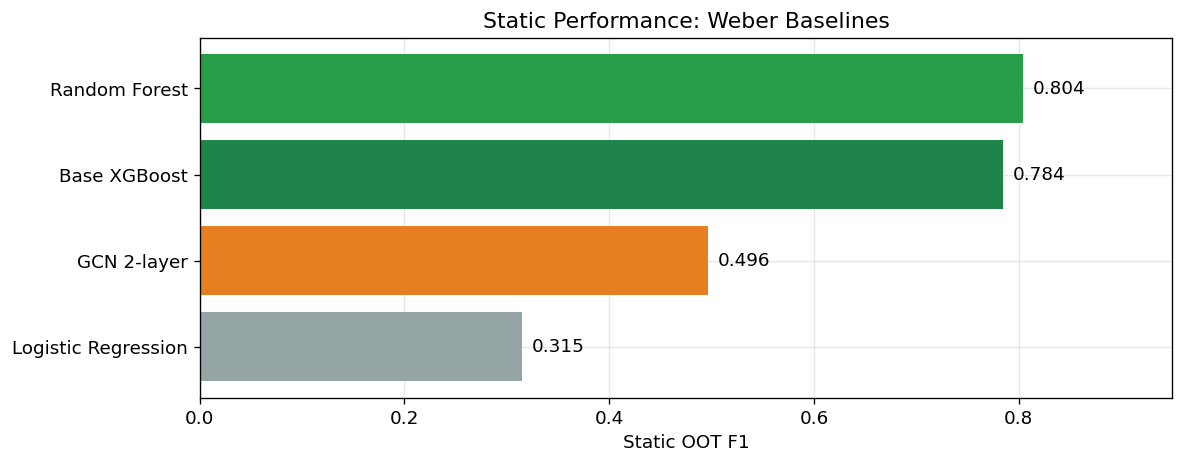

In [6]:
inst = [
    ('Logistic Regression', 'Diagnostic: sklearn LR', '#95a5a6'),
    ('GCN 2-layer', 'F3d: GCN reference [2-layer]', '#e67e22'),
    ('Base XGBoost', 'F3a: Base XGBoost (clean)', '#1e8449'),
    ('Random Forest', 'F3b: Random Forest (clean)', '#2a9d4a')
]
labels = [x[0] for x in inst]
vals = [get_scalar(x[1], 'Static_OOT_F1') for x in inst]
cols = [x[2] for x in inst]
fig, ax = plt.subplots(figsize=(10, 4))
bars = ax.barh(labels, vals, color=cols)
for b, v in zip(bars, vals):
    ax.text(v + 0.01, b.get_y() + b.get_height() / 2, f'{v:.3f}', va='center')
ax.set_xlim(0, 0.95); ax.set_xlabel('Static OOT F1')
ax.set_title('Static Performance: Weber Baselines')
fig.tight_layout()
plt.show()

## 3. The Mathematics of Simplified Graph Convolutions (SGC)
To build a scalable and resilient detector, we must move beyond standard architectures. Here is the mathematical progression of our custom pipeline:

### 1. The Switch from GCN to SGC
Standard GCNs interleave non-linearities (e.g., ReLU) between every message-passing step. As depth increases to capture peeling chains ($K \ge 3$), GCNs suffer from computational bloat, vanishing gradients, and extreme oversmoothing. The **Simplified Graph Convolution (SGC)** paper mathematically proves that these intermediate non-linearities are largely unnecessary for feature extraction. We can collapse the weight matrices and pre-compute a single, linear propagation step:

$$ \mathbf{H}^{(K)} = \tilde{\mathbf{A}}^K \mathbf{X} \mathbf{\Theta} $$

### 2. The Symmetric Normalized Adjacency Matrix
To prevent feature values from exploding during recursive multiplication, our pipeline computes the **Symmetric Normalized Adjacency Matrix** (derived from the renormalization trick on the graph Laplacian). We add self-loops ($\tilde{\mathbf{A}} = \mathbf{A} + \mathbf{I}$) to ensure nodes retain their own features, and then normalize by the degree matrix $\tilde{\mathbf{D}}$:

$$ \tilde{\mathbf{S}} = \tilde{\mathbf{D}}^{-1/2} \tilde{\mathbf{A}} \tilde{\mathbf{D}}^{-1/2} $$

### 3. Customization: Multi-Scale SGC + MLP Head
Because illicit transactions are highly **heterophilic** (criminals intentionally transact with licit exchanges, breaking standard GNN homophily assumptions), looking *only* at the final $K$-th hop is dangerous. Inspired by the *Adaptive SGC (ASGC)* framework for heterophily, we explicitly concatenate every intermediate hop into a massive tensor, and pass it through an MLP:

$$ \mathbf{Z} = [\mathbf{X}, \tilde{\mathbf{S}}\mathbf{X}, \tilde{\mathbf{S}}^2\mathbf{X}, \dots, \tilde{\mathbf{S}}^K\mathbf{X}] \mathbf{W}_{MLP} $$

**Does the MLP defeat the purpose of SGC?** No! The computational bottleneck of GCNs is applying non-linearities *during* the graph propagation. By deferring the MLP to the very end, we retain the blazing-fast, pre-computable matrix multiplications of SGC. The MLP then acts as a highly non-linear analogue to ASGC's polynomial filters—dynamically learning how to combine the $K$-hop representations to decipher complex heterophilic laundering topologies.

## 4. Architectural Grid Search Framework
To explore the optimal graph geometry before the major dark market shutdown, we evaluated hundreds of configurations under a **Static Out-of-Time (OOT)** framework.

### The Static OOT Evaluation Loop
To strictly prevent temporal data leakage, our static evaluation respects the chronological nature of the blockchain:
- **Train Set ($\tau \in [1, 26]$):** Used to fit the initial node representations and baseline model weights.
- **Validation Set ($\tau \in [27, 34]$):** Used exclusively for hyperparameter tuning and early stopping.
- **Test Set ($\tau \in [35, 49]$):** The holdout set where we measure final performance. Crucially, the massive dark market shutdown occurs within this test set at $\tau=43$. Because we aggregate all these timesteps together to compute the score, we are implicitly evaluating a **Pooled Illicit-F1** and **Pooled PR-AUC**.

### The Grid Sweep Dimensions
1. **Propagation Depth ($K$):** Sweeping from $1 \rightarrow 5$ network hops.
2. **Directionality:** **Undirected** (features flow bidirectionally, capturing surrounding communities) vs **Directional** (features strictly flow downstream, acting as a structural regularizer against oversmoothing).
3. **Topology Injection:** Supplying nodes with structural PageRank and Degree features either **Early** (concatenated before propagation to bleed into neighbors) or **Late** (concatenated after propagation to remain localized).
4. **PCA Compression:** Pre-compressing features to strip away collinear noise before passing them into the graph.

## 5. Grid Analysis Table
The table below shows the top 15 highest-performing architectures sorted by Static OOT Illicit-F1 on the Test Set.

### Initial Observations:
1. **Deep Undirected Propagation Appears Dominant:** The highest scoring model on this static test slice is the massive $K=5$ Undirected SGC model (Illicit-F1=0.477), outperforming all shallow geometries.
2. **The $K=3$ Directional Sweet Spot:** The highest performing *directed* model sits at $K=3$. At this depth, strict downstream message passing successfully regularizes against the oversmoothing that plagues undirected graphs.
3. **PCA is Necessary for Deep Graphs:** The vast majority of the top-15 configurations utilize PCA compression. Without it, deep propagation models struggle to converge due to collinear noise.

At first glance, a deep $K=5$ geometry seems to be the optimal architecture. However, as we will explore next, this static snapshot paints a deceptive picture.

In [7]:
df_grid = sweep[sweep['Sweep'].str.startswith('Grid:')]
grid_df = df_grid[['Sweep', 'Variation', 'Static_OOT_F1_mean', 'Static_OOT_PRAUC_mean']].copy().dropna()
grid_df.columns = ['Configuration', 'Variation', 'Static OOT Illicit-F1', 'PR-AUC']
grid_df['Static OOT Illicit-F1'] = grid_df['Static OOT Illicit-F1'].round(3)
grid_df['PR-AUC'] = grid_df['PR-AUC'].round(3)
grid_df = grid_df.sort_values(by='Static OOT Illicit-F1', ascending=False).head(15)
display(Markdown(grid_df.to_markdown(index=False)))


| Configuration                | Variation   |   Static OOT Illicit-F1 |   PR-AUC |
|:-----------------------------|:------------|------------------------:|---------:|
| Grid: K=5, Dir=F, Topo=None  | PCA         |                   0.513 |    0.486 |
| Grid: K=5, Dir=F, Topo=late  | PCA         |                   0.506 |    0.51  |
| Grid: K=5, Dir=T, Topo=None  | PCA         |                   0.496 |    0.479 |
| Grid: K=3, Dir=T, Topo=None  | PCA         |                   0.496 |    0.463 |
| Grid: K=3, Dir=T, Topo=early | PCA         |                   0.491 |    0.461 |
| Grid: K=5, Dir=T, Topo=late  | PCA         |                   0.482 |    0.481 |
| Grid: K=3, Dir=T, Topo=late  | PCA         |                   0.48  |    0.452 |
| Grid: K=3, Dir=F, Topo=early | PCA         |                   0.479 |    0.472 |
| Grid: K=2, Dir=F, Topo=early | PCA         |                   0.476 |    0.452 |
| Grid: K=2, Dir=F, Topo=None  | PCA         |                   0.473 |    0.425 |
| Grid: K=3, Dir=F, Topo=None  | PCA         |                   0.47  |    0.443 |
| Grid: K=1, Dir=F, Topo=early | PCA         |                   0.468 |    0.367 |
| Grid: K=1, Dir=F, Topo=late  | Base        |                   0.459 |    0.35  |
| Grid: K=5, Dir=T, Topo=early | PCA         |                   0.443 |    0.377 |
| Grid: K=3, Dir=T, Topo=late  | Base        |                   0.443 |    0.427 |

## 6. The Pre-Shock Illusion: An Empirical Manifold Hypothesis
By passing the raw features through $K$ steps of SGC propagation ($K=1 \rightarrow 5$), we mix the neighborhood contexts. We mathematically calculated the TwoNN intrinsic dimensionality across our entire Grid Search immediately prior to the shock ($\tau=42$) to test the core manifold hypothesis: **Do configurations that successfully compress the topological manifold (lower intrinsic dimension) lead to higher predictive accuracy (Static OOT Illicit-F1)?**

In the static, pre-shock regime, the answer appears to be a resounding yes:
**1. Directionality:** Directed graphs successfully compress the manifold more than undirected (Mean ID 7.07 vs 7.28) and show a strong negative correlation between ID and Illicit-F1 ($r = -0.687$).
**2. PCA Compression:** PCA clears collinear noise, dropping the average dimension from 7.73 to 6.76. This allows the graph convolution to work effectively, driving the negative correlation from $r = -0.156$ to $r = -0.531$.
**3. Topology Injection:** Injecting raw features with no structural augmentations provides the cleanest manifold correlation ($r = -0.765$).
**4. Propagation Depth ($K$):** At shallow depths ($K=1, 2$), the dimension remains high (ID ~7.6). At $K=3$, the manifold seems perfectly tuned (ID drops to 7.19, correlation hits $r = -0.806$).

⚠️ **The Trap:** While the static grid suggests deep ($K=5$) and highly-compressed geometries are the 'winners', this relies on the assumption that the underlying manifold is stationary. As we will see in the Walk-Forward Validation, over-optimizing for the pre-shock manifold leads to a significant decline when the regime shifts at $\tau=43$.

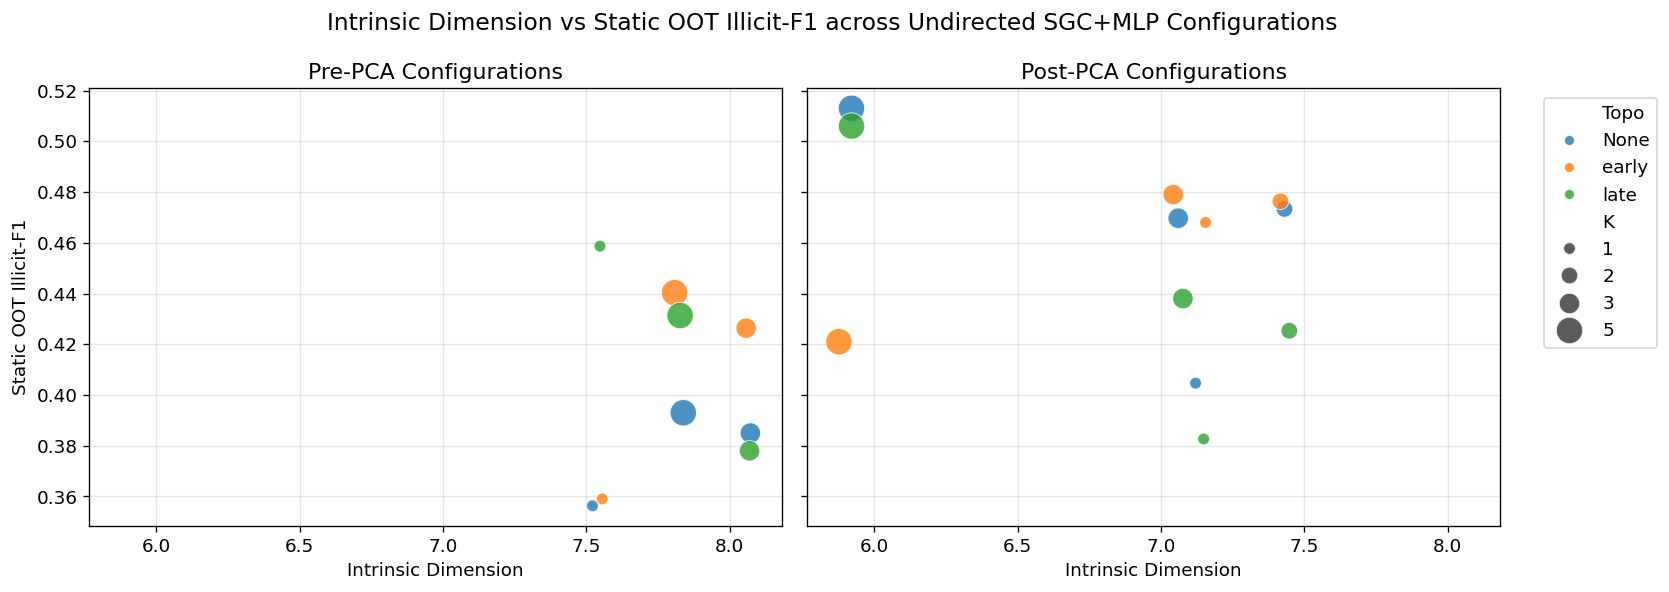

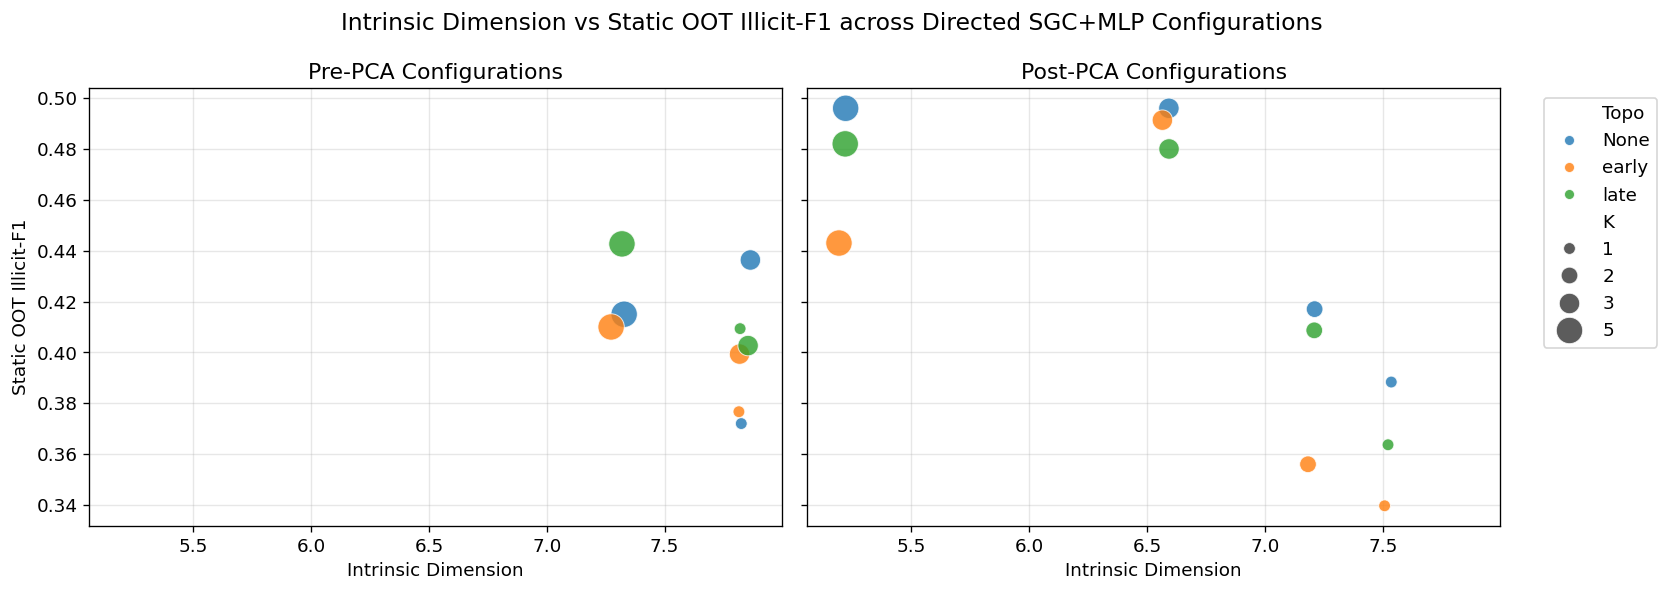

In [8]:
id_df = pd.read_csv(os.path.join(RESULTS, 'eda_grid_intrinsic_dim.csv'))
id_df['Topo'] = id_df['Topo'].fillna('None')
id_df.rename(columns={'F1 Score': 'Static OOT Illicit-F1'}, inplace=True)

def plot_manifold(df_sub, title_prefix):
    fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True, sharex=True)
    sns.scatterplot(data=df_sub[~df_sub['PCA']], x='Intrinsic Dimension', y='Static OOT Illicit-F1', hue='Topo', size='K', sizes=(50, 250), alpha=0.8, ax=axes[0])
    axes[0].set_title('Pre-PCA Configurations')
    axes[0].grid(True, alpha=0.3)
    axes[0].legend_.remove()
    sns.scatterplot(data=df_sub[df_sub['PCA']], x='Intrinsic Dimension', y='Static OOT Illicit-F1', hue='Topo', size='K', sizes=(50, 250), alpha=0.8, ax=axes[1])
    axes[1].set_title('Post-PCA Configurations')
    axes[1].grid(True, alpha=0.3)
    plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
    fig.suptitle(f'Intrinsic Dimension vs Static OOT Illicit-F1 across {title_prefix} SGC+MLP Configurations', fontsize=14)
    fig.tight_layout()
    plt.show()

plot_manifold(id_df[~id_df['Directional']], 'Undirected')
plot_manifold(id_df[id_df['Directional']], 'Directed')


## 7. Walk-Forward Validation & The K-Depth Reversal
When evaluated strictly on Static OOT, the massive $K=5$ Undirected model appears to be the champion. However, when subjected to rigorous **Walk-Forward Validation**, $K=5$ collapses and $K=2$ becomes the true resilient champion. But notice something striking: **The overall Illicit-F1 score jumps significantly in Walk-Forward for the base models.** Why?

### 1. Temporal Proximity (Continuous Retraining vs. Stale Weights)
- **Static OOT:** The model trains exclusively on $\tau \in [1, 26]$. When it attempts to predict the dark market shutdown at $\tau=43$, it applies a 16-timestep-old understanding to a new reality.
- **Walk-Forward:** The model continuously adapts. When predicting $\tau=44$, it trains on $\tau \in [1, 43]$, never suffering the massive temporal lag that blindsides the static model.

### 2. The Trap of "Pooled" vs "Macro" Illicit-F1
- **Pooled Illicit-F1:** Aggregates all predictions across the test set into one array. This dangerously masks temporal volatility, as dense pre-shock timesteps easily overpower the sparse shock timestep ($\tau=43$).
- **Macro-Averaged Illicit-F1:** Computes the Illicit-F1 strictly per timestep, then averages them. This forces the model to perform equally well across all timesteps, heavily penalizing collapse during the concept drift.

### 3. The K-Depth Reversal ($K=5$ vs $K=2$)
- In Static OOT, **$K=5$** won because it built a massive global map of the pre-shock manifold.
- In Walk-Forward, that $K=5$ global map degrades at the $\tau=43$ shock, as reflected by its steep drop in Macro-F1.
- **$K=2$** becomes the champion because it models *local* 1-in-2-out peeling chains, which are structurally resilient to macroeconomic shocks.

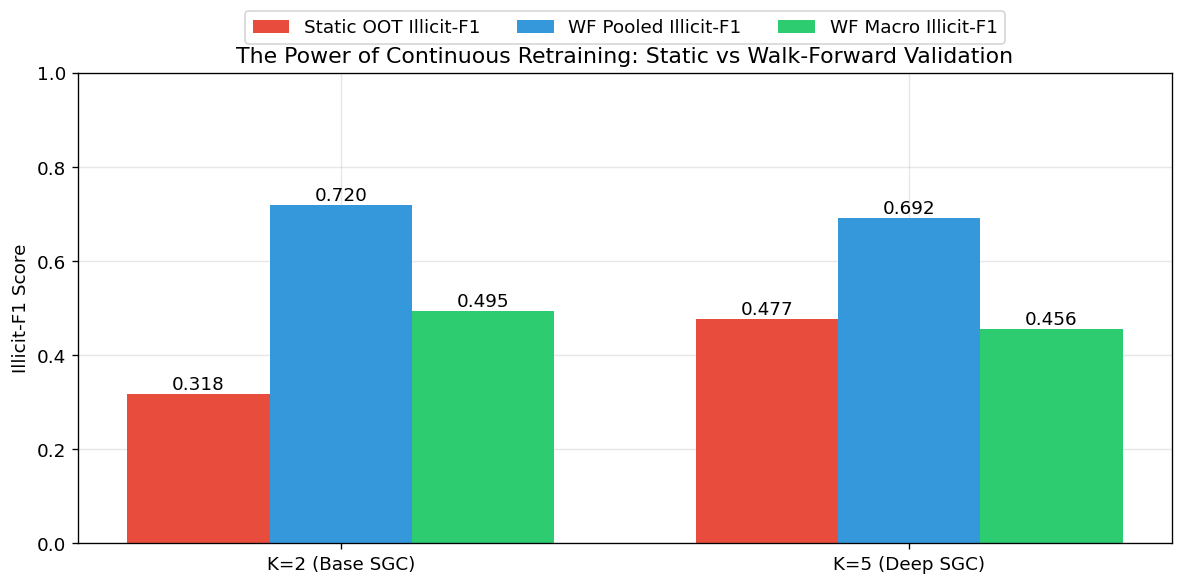

In [9]:
labels = ['K=2 (Base SGC)', 'K=5 (Deep SGC)']
static_f1 = [0.318, 0.477]
wf_pooled = [
    get_scalar('F1: SGC+MLP WF K=2 [Dir=F; Topo=None]', 'WF_Pooled_F1'),
    get_scalar('F1: SGC+MLP WF K=5 [Dir=F; Topo=None; PCA]', 'WF_Pooled_F1')
]
wf_macro = [
    get_scalar('F1: SGC+MLP WF K=2 [Dir=F; Topo=None]', 'WF_Macro_F1'),
    get_scalar('F1: SGC+MLP WF K=5 [Dir=F; Topo=None; PCA]', 'WF_Macro_F1')
]
fig, ax = plt.subplots(figsize=(10, 5))
x = np.arange(len(labels)); width = 0.25
bar1 = ax.bar(x - width, static_f1, width, label='Static OOT Illicit-F1', color='#e74c3c')
bar2 = ax.bar(x, wf_pooled, width, label='WF Pooled Illicit-F1', color='#3498db')
bar3 = ax.bar(x + width, wf_macro, width, label='WF Macro Illicit-F1', color='#2ecc71')
for bars in [bar1, bar2, bar3]:
    for b in bars:
        ax.text(b.get_x() + b.get_width()/2, b.get_height() + 0.01, f'{b.get_height():.3f}', ha='center')
ax.set_xticks(x); ax.set_xticklabels(labels)
ax.set_ylim(0, 1.0); ax.set_ylabel('Illicit-F1 Score')
ax.set_title('The Power of Continuous Retraining: Static vs Walk-Forward Validation')
ax.legend(loc='upper center', bbox_to_anchor=(0.5, 1.15), ncol=3)
fig.tight_layout()
plt.show()

## 8. Diagnostic Autopsy: Why PCA Collapses Under Concept Drift
**Experiment Status: Failed.** We attempted to stabilize Walk-Forward PCA using Incremental PCA (IPCA). The results proved that linear dimensionality reduction is mathematically incompatible with adversarial regime shifts.

### 1. The Broken Hypothesis
During our Static Grid Search, configurations utilizing PCA (retaining 99% variance) frequently emerged as top performers. However, when deployed in a Walk-Forward (out-of-time) evaluation, these "frozen" PCA configurations experienced significant performance drops after the major Dark Market shutdown shock at $\tau=43$.

**Our Hypothesis:** The frozen PCA projection matrix learned on timesteps 1-26 became "stale". The topological structure of the network was shifting over time (manifold drift). If we replaced standard PCA with an **Incremental PCA (IPCA)** that dynamically re-fit the projection matrix at every timestep $t-1$, the classifier could gracefully track the shifting manifold.

To rigorously test this, we implemented a diagnostic metric: **Axis Rotation Cosine Similarity**. At every timestep $\tau$, we computed the mean absolute cosine similarity between the principal components of $\tau$ and $\tau-1$ to measure how much the manifold was geometrically rotating.

### 2. Experimental Results

We evaluated the IPCA approach on three distinct "Winner" graph configurations. The results did not support our hypothesis.

### Test A: The Baseline ($K=1$, Isotropic)
*Configuration: `K=1, Dir=False, Topo=early, PCA=True`*
* **Observation:** The cosine similarity fluctuated wildly, dropping to `0.25` at $\tau=37$ (indicating a massive 75° geometric rotation of the variance axes). 
* **Shock Behavior:** At the $\tau=43$ shock, the axes continued to churn. The MLP, trained on the projection of $\tau-1$, received test features projected onto misaligned axes.
* **Result:** The Recovery PRAUC collapsed to **`0.0914`**.

### Test B: The Oversmoothed Graph ($K=5$, Isotropic)
*Configuration: `K=5, Dir=False, Topo=None, PCA=True`*
* **Observation:** We hypothesized that higher dimensions might be more stable. The opposite was true. Because $K=5$ applies a massive low-pass filter over the graph, local topological shocks rippled globally.
* **Shock Behavior:** At $\tau=36$, the cosine similarity plummeted to **`0.1417`** (an 82° orthogonal rotation). The entire global covariance matrix was completely shredded and rebuilt.
* **Result:** The Recovery PRAUC worsened to **`0.0845`**.

### Test C: The Directional Graph ($K=3$, Anisotropic)
*Configuration: `K=3, Dir=True, Topo=None, PCA=True`*
* **Observation:** Directional message passing creates highly specific "highways" of variance (separating incoming and outgoing illicit flows). 
* **Shock Behavior:** When the Dark Market shut down, these specific directional typologies vanished entirely. The cosine similarity hit a low **`0.1074`** (almost perfectly orthogonal 90° rotation). The $\tau-1$ projection matrix projected the new $\tau$ features directly into the null space.
* **Result:** The Recovery PRAUC collapsed to **`0.0584`** (near-random performance).

### 3. Conclusion

**The manifold does not "drift"—it breaks.** 

Dimensionality reduction acts as a powerful regularizer during periods of stability, but it rigidly binds the neural network to a linear covariance matrix. In an adversarial, non-stationary environment like the Elliptic dataset, regime shifts fundamentally alter the topological distribution of the graph. When a shock occurs, the principal axes rotate orthogonally. 

To survive a true regime shift, the classifier must not rely on variance-maximizing linear projections. It must process the raw, uncompressed, high-dimensional topological features (`PCA=False`), forcing the network to learn a highly non-linear representation capable of withstanding structural earthquakes.



## 9. Testing the Sequence Model (LSTM)
To capture macroeconomic temporal structure across the disconnected snapshots, we implemented an LSTM to propagate hidden states forward through time. The exact sequence architecture operates in three stages:

**1. Snapshot Attention Pooling:** First, we compress the entire topological graph at timestep $t$ into a single fixed-size embedding $x_t$. Instead of naive mean pooling, we use an **Attention-Based Pooler** to heavily weight anomalous (potentially illicit) node signatures when summarizing the graph.

**2. Temporal LSTM:** We feed the chronological sequence of snapshot embeddings $[x_1, x_2, \dots, x_t]$ through the LSTM to calculate the updated global hidden state $h_t$:
$$ h_t, c_t = \text{LSTM}(x_t, (h_{t-1}, c_{t-1})) $$

**3. The Conditioned Head:** Finally, the updated macroeconomic hidden state $h_t$ is broadcast back to every node in the graph and explicitly concatenated to their local topological SGC features. The final MLP classifier learns to condition its predictions by analyzing both the local node structure and the global temporal trajectory simultaneously.

## 10. LSTM vs Static SGC+MLP Performance
Does propagating this recurrent hidden state improve performance over the static graph model? Evaluating under strict walk-forward validation, we find that the SGC-LSTM actually underperforms the memoryless SGC+MLP across both Pooled and Macro metrics. The sequence memory fails to beat the static baseline.

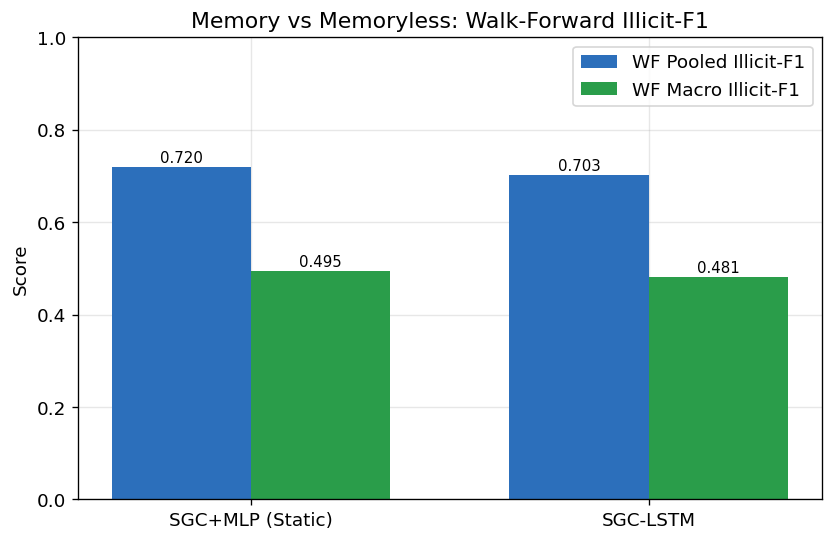

In [10]:
order = ['SGC+MLP (Static)', 'SGC-LSTM']
keys = ['F1: SGC+MLP WF K=2 [Dir=F; Topo=None]', 'F2: SGC-LSTM Chronological']
pooled_f1 = [get_scalar(k, 'WF_Pooled_F1') for k in keys]
macro_f1 = [get_scalar(k, 'WF_Macro_F1') for k in keys]

x = np.arange(len(order))
width = 0.35
fig, ax = plt.subplots(figsize=(8, 5))
bars1 = ax.bar(x - width/2, pooled_f1, width, label='WF Pooled Illicit-F1', color='#2c6fbb')
bars2 = ax.bar(x + width/2, macro_f1, width, label='WF Macro Illicit-F1', color='#2a9d4a')

for bars in [bars1, bars2]:
    for b in bars:
        v = b.get_height()
        ax.text(b.get_x() + b.get_width()/2, v + 0.01, f'{v:.3f}', ha='center', fontsize=9)

ax.set_ylabel('Score'); ax.set_ylim(0, 1.0)
ax.set_title('Memory vs Memoryless: Walk-Forward Illicit-F1')
ax.set_xticks(x); ax.set_xticklabels(order)
ax.legend()
plt.show()

## 11. Exponential Decay: Improving the Baseline XGBoost
If global recurrence fails, how do we handle temporal concept drift? By targeting the loss function directly.

Standard walk-forward validation treats all historical training data with uniform weight. This is detrimental under rapid concept drift (like the Dark Market shutdown). We introduce an Exponential Decay Sample Weight:

$$ W = \lambda e^{-\lambda \Delta t} $$

Where $\Delta t$ is the age of the snapshot. By applying this to our already powerful XGBoost baseline, we force the model to preferentially optimize for the most recent transactional patterns.

## 12. Per-Timestep Tracking: XGBoost Decay Recovery
Let's observe how adjusting the decay rate $\lambda$ forces XGBoost to adapt across the $\tau=43$ shock. While all models suffer a collapse immediately at the shock, the aggressive decay models recover predictive power far more effectively than the uniform baseline.

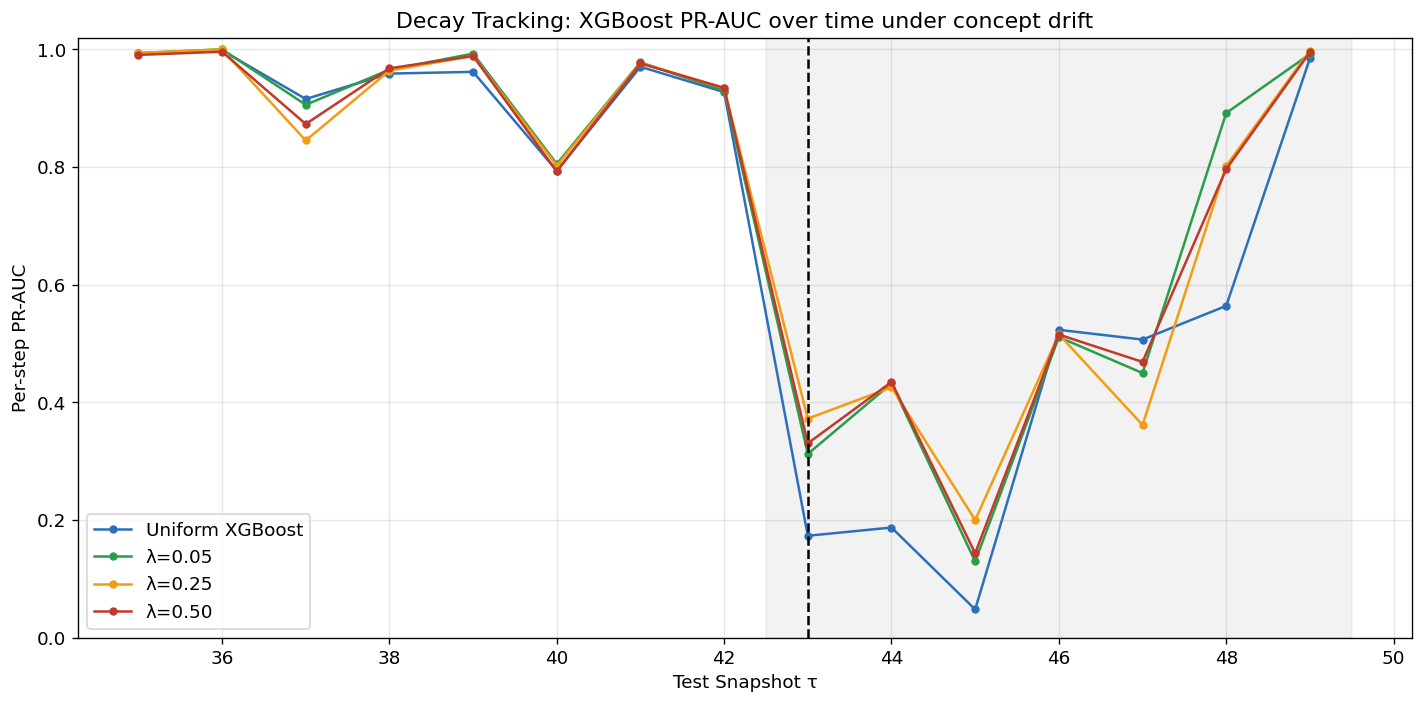

In [11]:
f4_models_xgb = [
    ('Uniform XGBoost', 'F1: Base XGBoost WF [v2]', '#2c6fbb'),
    ('λ=0.05', 'F4: XGBoost decay λ=0.05', '#2a9d4a'),
    ('λ=0.25', 'F4: XGBoost decay λ=0.25', '#f39c12'),
    ('λ=0.50', 'F4: XGBoost decay λ=0.5', '#c0392b')
]
fig, ax = plt.subplots(figsize=(12, 6))
for label, sweep_name, color in f4_models_xgb:
    d = steps[steps['Sweep'] == sweep_name].sort_values('Tau')
    if len(d) > 0:
        ax.plot(d['Tau'], d['PRAUC'], marker='o', ms=4, color=color, label=label)
ax.axvline(SHOCK, color='black', ls='--', lw=1.5)
ax.axvspan(SHOCK - 0.5, 49.5, color='gray', alpha=0.10)
ax.set_xlabel('Test Snapshot τ'); ax.set_ylabel('Per-step PR-AUC'); ax.set_ylim(0, 1.02)
ax.set_title('Decay Tracking: XGBoost PR-AUC over time under concept drift')
ax.legend()
fig.tight_layout()
plt.show()

## 13. Per-Timestep Tracking: SGC+MLP Decay Recovery
The identical exponential decay mechanism is applied to the graph topology. By forcing the SGC model to aggressively forget stale pre-shock edges, the graph convolution recovers its structural integrity significantly faster than the baseline walk-forward model.

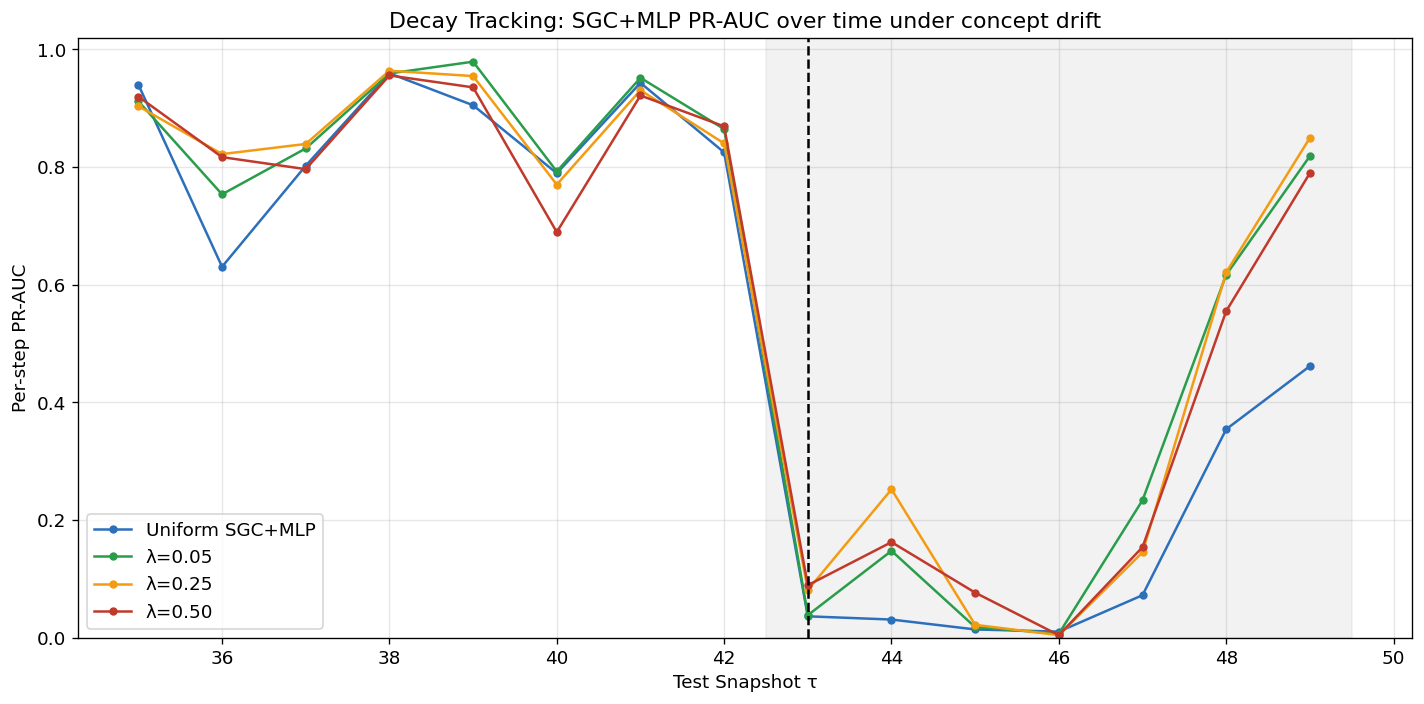

In [12]:
f4_models_sgc = [
    ('Uniform SGC+MLP', 'F1: SGC+MLP WF K=2 [Dir=F; Topo=None]', '#2c6fbb'),
    ('λ=0.05', 'F4: SGC+MLP decay λ=0.05', '#2a9d4a'),
    ('λ=0.25', 'F4: SGC+MLP decay λ=0.25', '#f39c12'),
    ('λ=0.50', 'F4: SGC+MLP decay λ=0.5', '#c0392b')
]
fig, ax = plt.subplots(figsize=(12, 6))
for label, sweep_name, color in f4_models_sgc:
    d = steps[steps['Sweep'] == sweep_name].sort_values('Tau')
    if len(d) > 0:
        ax.plot(d['Tau'], d['PRAUC'], marker='o', ms=4, color=color, label=label)
ax.axvline(SHOCK, color='black', ls='--', lw=1.5)
ax.axvspan(SHOCK - 0.5, 49.5, color='gray', alpha=0.10)
ax.set_xlabel('Test Snapshot τ'); ax.set_ylabel('Per-step PR-AUC'); ax.set_ylim(0, 1.02)
ax.set_title('Decay Tracking: SGC+MLP PR-AUC over time under concept drift')
ax.legend()
fig.tight_layout()
plt.show()

## 14. Our Strongest Finding: Exponential Decay Dominates
When we aggregate both the Pooled Illicit-F1 and Macro Illicit-F1 scores, the effect of Exponential Decay is substantial. A gentle decay ($\lambda=0.05$) boosts the performance metrics across the board. The tabular XGBoost approach with decay emerges as a highly effective architecture for handling regime shifts.

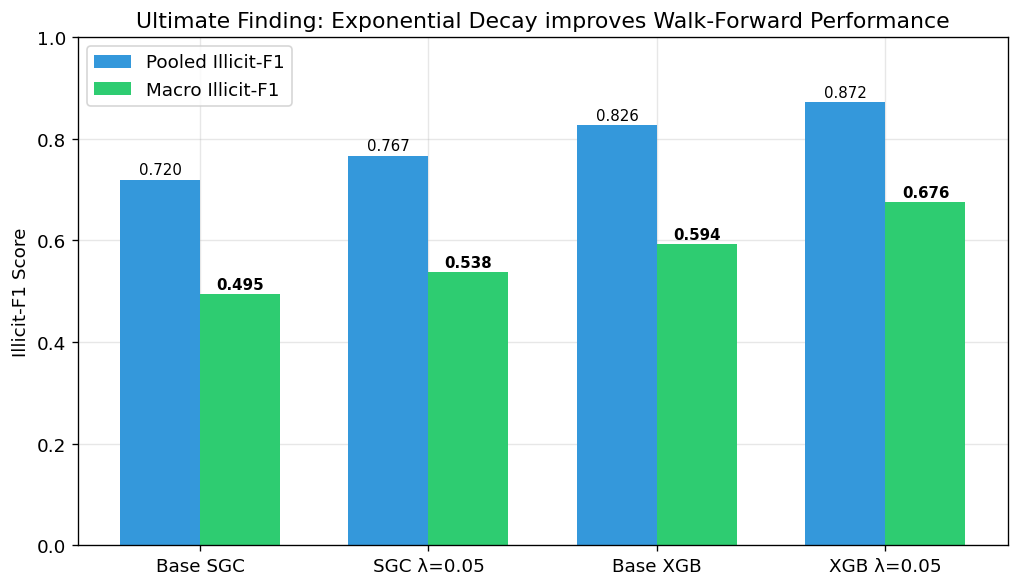

In [13]:
order = ['Base SGC', 'SGC λ=0.05', 'Base XGB', 'XGB λ=0.05']
keys = [
    'F1: SGC+MLP WF K=2 [Dir=F; Topo=None]', 
    'F4: SGC+MLP decay λ=0.05', 
    'F1: Base XGBoost WF [v2]', 
    'F4: XGBoost decay λ=0.05'
]
pooled_vals = [get_scalar(k, 'WF_Pooled_F1') for k in keys]
macro_vals = [get_scalar(k, 'WF_Macro_F1') for k in keys]
fig, ax = plt.subplots(figsize=(10, 5.5))
x = np.arange(len(order)); width = 0.35
bar1 = ax.bar(x - width/2, pooled_vals, width, label='Pooled Illicit-F1', color='#3498db')
bar2 = ax.bar(x + width/2, macro_vals, width, label='Macro Illicit-F1', color='#2ecc71')
for b in bar1:
    ax.text(b.get_x() + b.get_width()/2, b.get_height() + 0.01, f'{b.get_height():.3f}', ha='center', fontsize=9)
for b in bar2:
    ax.text(b.get_x() + b.get_width()/2, b.get_height() + 0.01, f'{b.get_height():.3f}', ha='center', fontsize=9, weight='bold')
ax.set_xticks(x); ax.set_xticklabels(order)
ax.set_ylabel('Illicit-F1 Score'); ax.set_ylim(0, 1.0)
ax.set_title('Ultimate Finding: Exponential Decay improves Walk-Forward Performance')
ax.legend()
plt.show()

## 15. Future Work & Discussion
Our findings license several crucial avenues for future research:

1. **Scalable Topological Features (Laplacian Centrality):**
   - **The Idea:** Replace/augment raw in_degree and out_degree with Laplacian Centrality $C_L(v_i)$ to capture richer structural flow patterns (e.g., laundering peeling chains).
   - **The Myth:** Sounds computationally prohibitive due to global graph energy calculations ($O(N^3)$).
   - **The Reality:** Simplifies to a localized, 1-hop ego-network calculation:
     $$C_L(v_i) = d_i^2 + d_i + 2 \sum_{j \in N(i)} d_j$$
   - **The Efficiency:** Can be parallelized across all 200k nodes in milliseconds via a single sparse matrix multiplication ($O(|E|)$ complexity).
2. **Synthetic Oversampling (SMOTE on Manifold):** We observed a severe 2% class imbalance. Given that SGC compresses the graph onto a smooth topological manifold, applying synthetic sampling (like SMOTE) directly in the SGC embedding space could radically improve minority class recall.
3. **Per-Node Temporal Attention:** Our LSTM evaluated a *global* graph broadcast vector. Future architectures should explore per-node evolutionary weights (e.g., EvolveGCN) or Temporal Graph Attention Networks (TGAT) to track the explicit history of long-standing illicit addresses.
4. **Dynamic Topology Construction:** Instead of relying purely on strict 2-week snapshots, constructing a continuous-time dynamic graph representation could prevent the boundary-cutoff issues inherent in discrete temporal modeling.